<hr size=5 color='#002883'>

<p align="center"> <font size=7 color='#002883'> Meteorologia Sinótica III (2025)

<p align="left"> <font size=5 color='#002883'> Professores:  

* Prof. Dr. Pedro Leite da Silva Dias
* Prof. Dr. Ricardo Hallak


<p align="left"> <font size=5 color='#002883'> Monitor:

* Ronald Guiuseppi Ramírez Nina [PhD. Candidate in Atmospheric Sciences]
* email: ronald.ramirez.nina@alumni.usp.br

<hr size=5 color='#002883'>

<hr size=5 color='#002883'>

**<p align="center"> <font size=8 color='#002883'> Elaboração de perfis veticais dos termos do balanço de vorticidade, calor e umidade em nas diferentes fases do ciclone**

<hr size=5 color='#002883'>


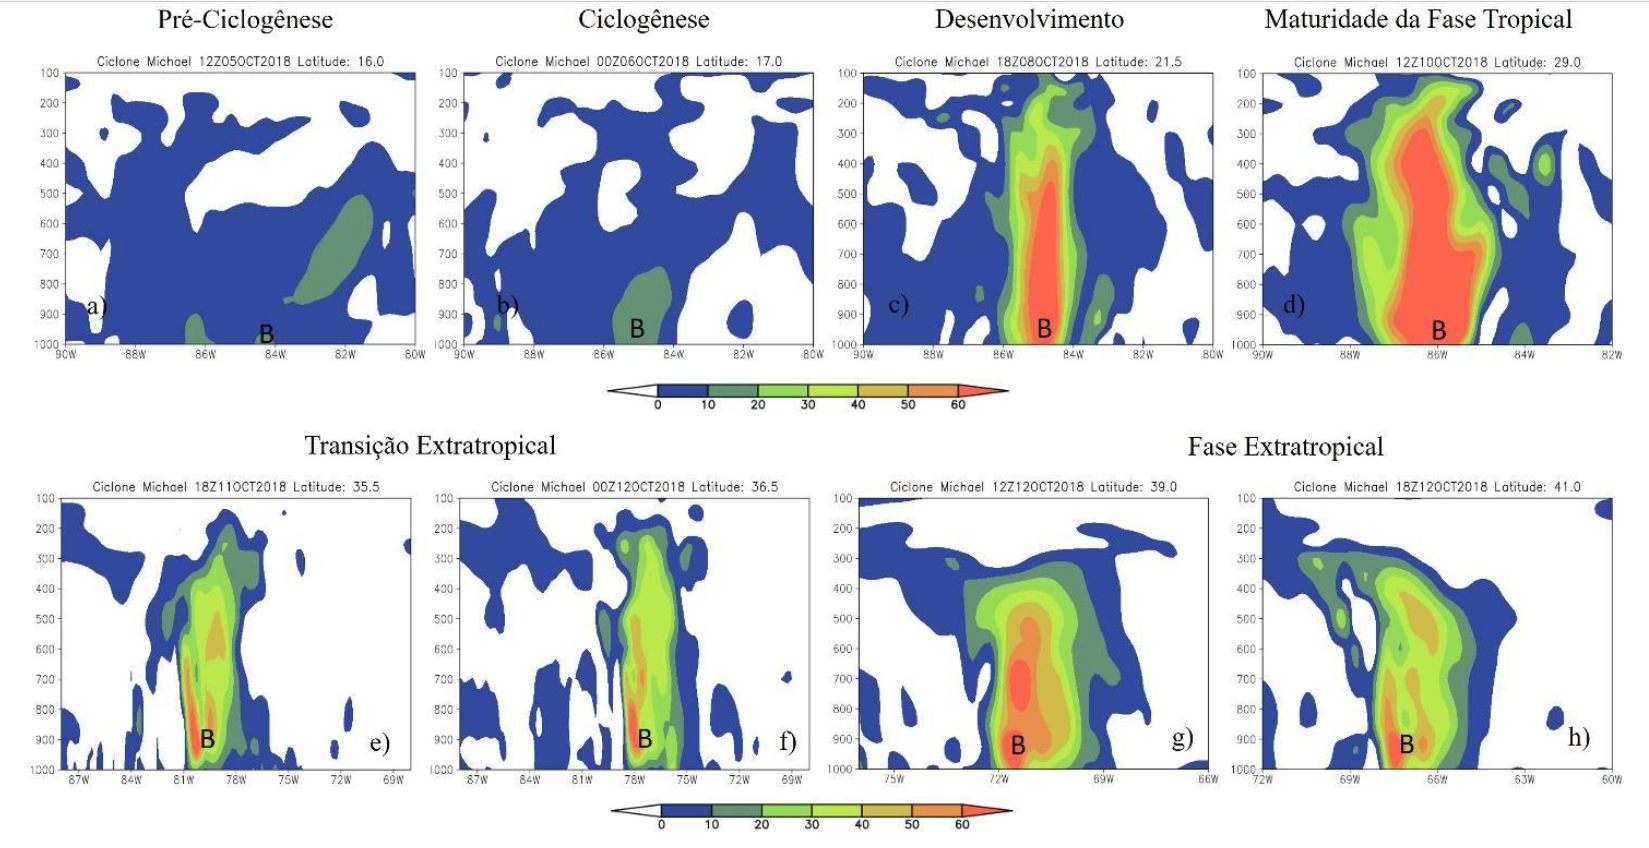

Figura extraída de:
- Pereira, Raquel & Araujo, Aline & Reboita, Michelle. (2021). Ciclone Michael: gênese e transição extratropical. Revista Brasileira de Geografia Física. 14. 298. 10.26848/rbgf.v14.1.p298-309.

- DOI: 10.26848/rbgf.v14.1.p298-309

<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **1. preparação do Colab** <font>

<font size=4 color='#002883'> Executar as duas células de abaixo: <font>

In [1]:
# @title #### <font color='#002883'> Instalar livrarias <font>
%%capture
!pip install cartopy
!pip install cmocean
!pip install xarray dask netCDF4 bottleneck pydap

<font size=4 color='#002883'> **2. Importar livrarias e montar o drive** <font>

In [2]:
# @title #### <font color='#002883'> Importar librarias  numpy, pandas, xarray, e outras <font>
%%capture

# Livrarias para ler e processar dados
import xarray as xr
import pandas as pd
import numpy as np

# Livrarias para gerar gráficos
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cmocean as cmo
import os

# Importar o drive
from google.colab import drive
drive.mount('/content/drive')

<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **3. Acessar aos resultados dos termos do Balanço de Calor do evento de ciclone entre 05-12-2025 até o dia 15-12-2025** <font>

In [20]:
# @title ## <font color='#002883'> Configurtações gerais para o balanço de calor<font>
%%capture

# =====================================================
# Configurações gerais
# =====================================================

budget = 'heat'

# Caminho da pasta com os resultados do ATMOS-BUD no drive
# (MODIFICAR PARA SEU CASO)
path_drive = '/content/drive/MyDrive/USP-CURSOS/MONITORIA/METEOROLOGIA-SINOTICA-III-2026/Aula-2_Hovmoller_Perfis-verticais'
path_terms = os.path.join(path_drive, f'ciclone_dec_2025_track/{budget}_terms')

# Fases do ciclone
fases = [
    ("Incipiente",        "2025-12-05 00:00", "2025-12-08 12:00"),
    ("Intensificação",    "2025-12-08 12:00", "2025-12-10 18:00"),
    ("Madura",            "2025-12-10 18:00", "2025-12-13 06:00"),
    ("Desintensificação", "2025-12-13 06:00", "2025-12-15 18:00"),
]

# Cores para os termos
colors_terms = [
    "#81d8f7", "#1a94d0", "#730000", "#db0000", "#f47920", "#f9b233",
    "#00ff00", "#3fae2a", "#00c1a1", "#138d75", "#ef7d90", "#cfcfcf",
    "#f6a6e1", "#b23aff", "#8377d1", "#8a9aff", "#b4e3ce",
]

<font size=4 color='#002883'> **4. Configurar DataFrame para fazer o plot dos perfis verticais dos termos do balanço de calor** <font>

Arquivos encontrados para plot:
 - AdvHTemp.csv
 - AdvVTemp.csv
 - ResT.csv
 - dTdt.csv


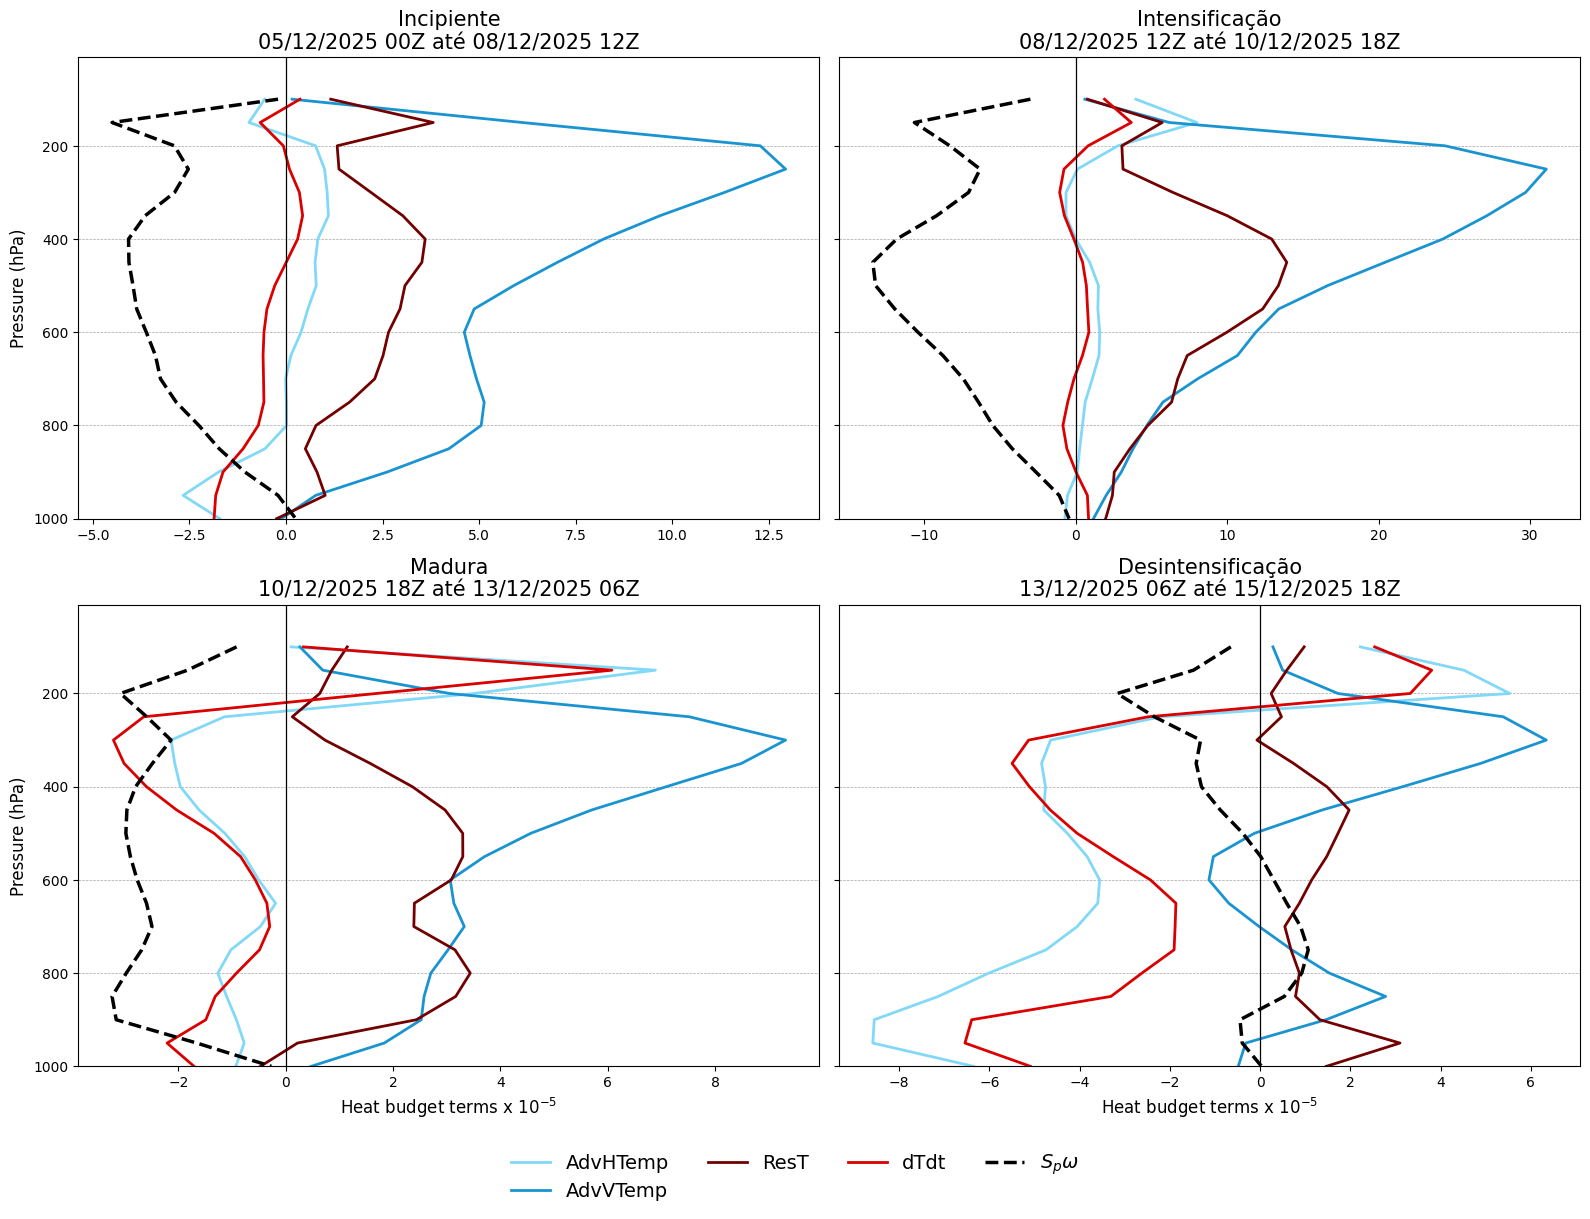

In [21]:
# @title ## <font color='#002883'> Ler .csv files do balanço de calor e fazer o plot considerando o produto de Sigma x Sp <font>

import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Selecionar arquivos .csv dos termos do balanço de calor
# =====================================================
all_files = sorted([f for f in os.listdir(path_terms) if f.endswith('.csv')])

# Excluir variáveis que você não quer plotar diretamente
files = []
for f in all_files:
    variable = f.split('.')[0]

    if variable in ['vxBeta', 'Zeta', 'Omega', 'Sigma']:
        continue
    if 'integrated' in variable:
        continue

    files.append(f)

print("Arquivos encontrados para plot:")
for f in files:
    print(" -", f)

# =====================================================
# Ler Omega e Sigma separadamente para calcular o produto
# =====================================================
file_omega = os.path.join(path_terms, "Omega.csv")
file_sigma = os.path.join(path_terms, "Sigma.csv")

df_omega = pd.read_csv(file_omega, index_col=0)
df_sigma = pd.read_csv(file_sigma, index_col=0)

# Converter colunas para datetime
df_omega.columns = pd.to_datetime(df_omega.columns)
df_sigma.columns = pd.to_datetime(df_sigma.columns)

# Converter índice de Pa para hPa
df_omega.index = pd.to_numeric(df_omega.index, errors='coerce') / 100
df_sigma.index = pd.to_numeric(df_sigma.index, errors='coerce') / 100

# Garantir valores numéricos
df_omega = df_omega.apply(pd.to_numeric, errors='coerce')
df_sigma = df_sigma.apply(pd.to_numeric, errors='coerce')

# Garantir compatibilidade entre os dois DataFrames
common_index = df_omega.index.intersection(df_sigma.index)
common_columns = df_omega.columns.intersection(df_sigma.columns)

df_omega = df_omega.loc[common_index, common_columns]
df_sigma = df_sigma.loc[common_index, common_columns]

# Produto S_p * omega
df_spomega = df_sigma * df_omega

# ==========================================================
# Criar figura com 2 linhas x 2 colunas
# ==========================================================
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# ==========================================================
# Loop sobre as fases
# ==========================================================
for ax, (fase_nome, start_date, end_date) in zip(axes, fases):

    i = 0

    # ------------------------------------------------------
    # Loop sobre os arquivos/termos originais
    # ------------------------------------------------------
    for file in files:
        variable = file.split('.')[0]

        # Ler CSV
        df = pd.read_csv(os.path.join(path_terms, file), index_col=0)

        # Converter colunas para datetime
        df.columns = pd.to_datetime(df.columns)

        # Converter índice de Pa para hPa
        df.index = pd.to_numeric(df.index, errors='coerce') / 100

        # Garantir que os dados são numéricos
        df = df.apply(pd.to_numeric, errors='coerce')

        # Selecionar o período da fase
        selected_data = df.loc[:, pd.to_datetime(start_date):pd.to_datetime(end_date)]

        # Média temporal da fase
        selected_data_mean = selected_data.mean(axis=1) * 1e5

        # Plotar perfil vertical médio
        ax.plot(
            selected_data_mean.values,
            selected_data_mean.index,
            color=colors_terms[i % len(colors_terms)],
            linewidth=2,
            linestyle='solid',
            label=variable
        )

        i += 1

    # ------------------------------------------------------
    # Adicionar o termo S_p * omega
    # ------------------------------------------------------
    selected_spomega = df_spomega.loc[:, pd.to_datetime(start_date):pd.to_datetime(end_date)]
    selected_spomega_mean = selected_spomega.mean(axis=1) * 1e5

    ax.plot(
        selected_spomega_mean.values,
        selected_spomega_mean.index,
        color='black',
        linewidth=2.5,
        linestyle='--',
        label=r'$S_p\omega$'
    )

    # ------------------------------------------------------
    # Ajustes do subplot
    # ------------------------------------------------------
    ax.axvline(0, color='k', linewidth=0.9)
    ax.invert_yaxis()
    ax.set_ylim(1000, 10)
    ax.grid(axis='y', linestyle='--', color='gray', alpha=0.7, linewidth=0.5)

    ax.set_title(
        f'{fase_nome}\n{pd.to_datetime(start_date).strftime("%d/%m/%Y %HZ")} até {pd.to_datetime(end_date).strftime("%d/%m/%Y %HZ")}',
        fontsize=15
    )

    ax.tick_params(axis='both', labelsize=10)

# ==========================================================
# Labels apenas na borda externa
# ==========================================================
for ax in axes[2:]:
    ax.set_xlabel('Heat budget terms x $10^{-5}$', fontsize=12)

for ax in [axes[0], axes[2]]:
    ax.set_ylabel('Pressure (hPa)', fontsize=12)

# ==========================================================
# Legenda geral
# ==========================================================
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=4,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

# ==========================================================
# Ajuste final e salvar figura
# ==========================================================
plt.tight_layout(rect=[0, 0.05, 1, 1])

path_out = os.path.join(path_drive, 'ciclone_dec_2025_track', 'Figuras_Perfis_Verticais')
os.makedirs(path_out, exist_ok=True)

plt.savefig(
    os.path.join(path_out, f'vertical_profiles_4phases_{budget}.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **5. Acessar aos resultados dos termos do Balanço de Vorticidade do evento de ciclone entre 05-12-2025 até o dia 15-12-2025** <font>

In [23]:
# @title ## <font color='#002883'> Configurtações gerais para o balanço de vorticidade<font>
%%capture

# =====================================================
# Configurações gerais
# =====================================================

budget = 'vorticity'

# Caminho da pasta com os resultados do ATMOS-BUD no drive
# (MODIFICAR PARA SEU CASO)
path_drive = '/content/drive/MyDrive/USP-CURSOS/MONITORIA/METEOROLOGIA-SINOTICA-III-2026/Aula-2_Hovmoller_Perfis-verticais'
path_terms = os.path.join(path_drive, f'ciclone_dec_2025_track/{budget}_terms')

# Fases do ciclone
fases = [
    ("Incipiente",        "2025-12-05 00:00", "2025-12-08 12:00"),
    ("Intensificação",    "2025-12-08 12:00", "2025-12-10 18:00"),
    ("Madura",            "2025-12-10 18:00", "2025-12-13 06:00"),
    ("Desintensificação", "2025-12-13 06:00", "2025-12-15 18:00"),
]

# Cores para os termos
colors_terms = [
    "#81d8f7", "#1a94d0", "#730000", "#db0000", "#f47920", "#f9b233",
    "#00ff00", "#3fae2a", "#00c1a1", "#138d75", "#ef7d90", "#cfcfcf",
    "#f6a6e1", "#b23aff", "#8377d1", "#8a9aff", "#b4e3ce",
]

<font size=4 color='#002883'> **6. Configurar DataFrame para fazer o plot dos termos do balanço de vorticidade** <font>

Arquivos encontrados para plot:
 - AdvHZeta.csv
 - AdvVZeta.csv
 - ResZ.csv
 - Tilting.csv
 - ZetaDivH.csv
 - dZdt.csv
 - fDivH.csv


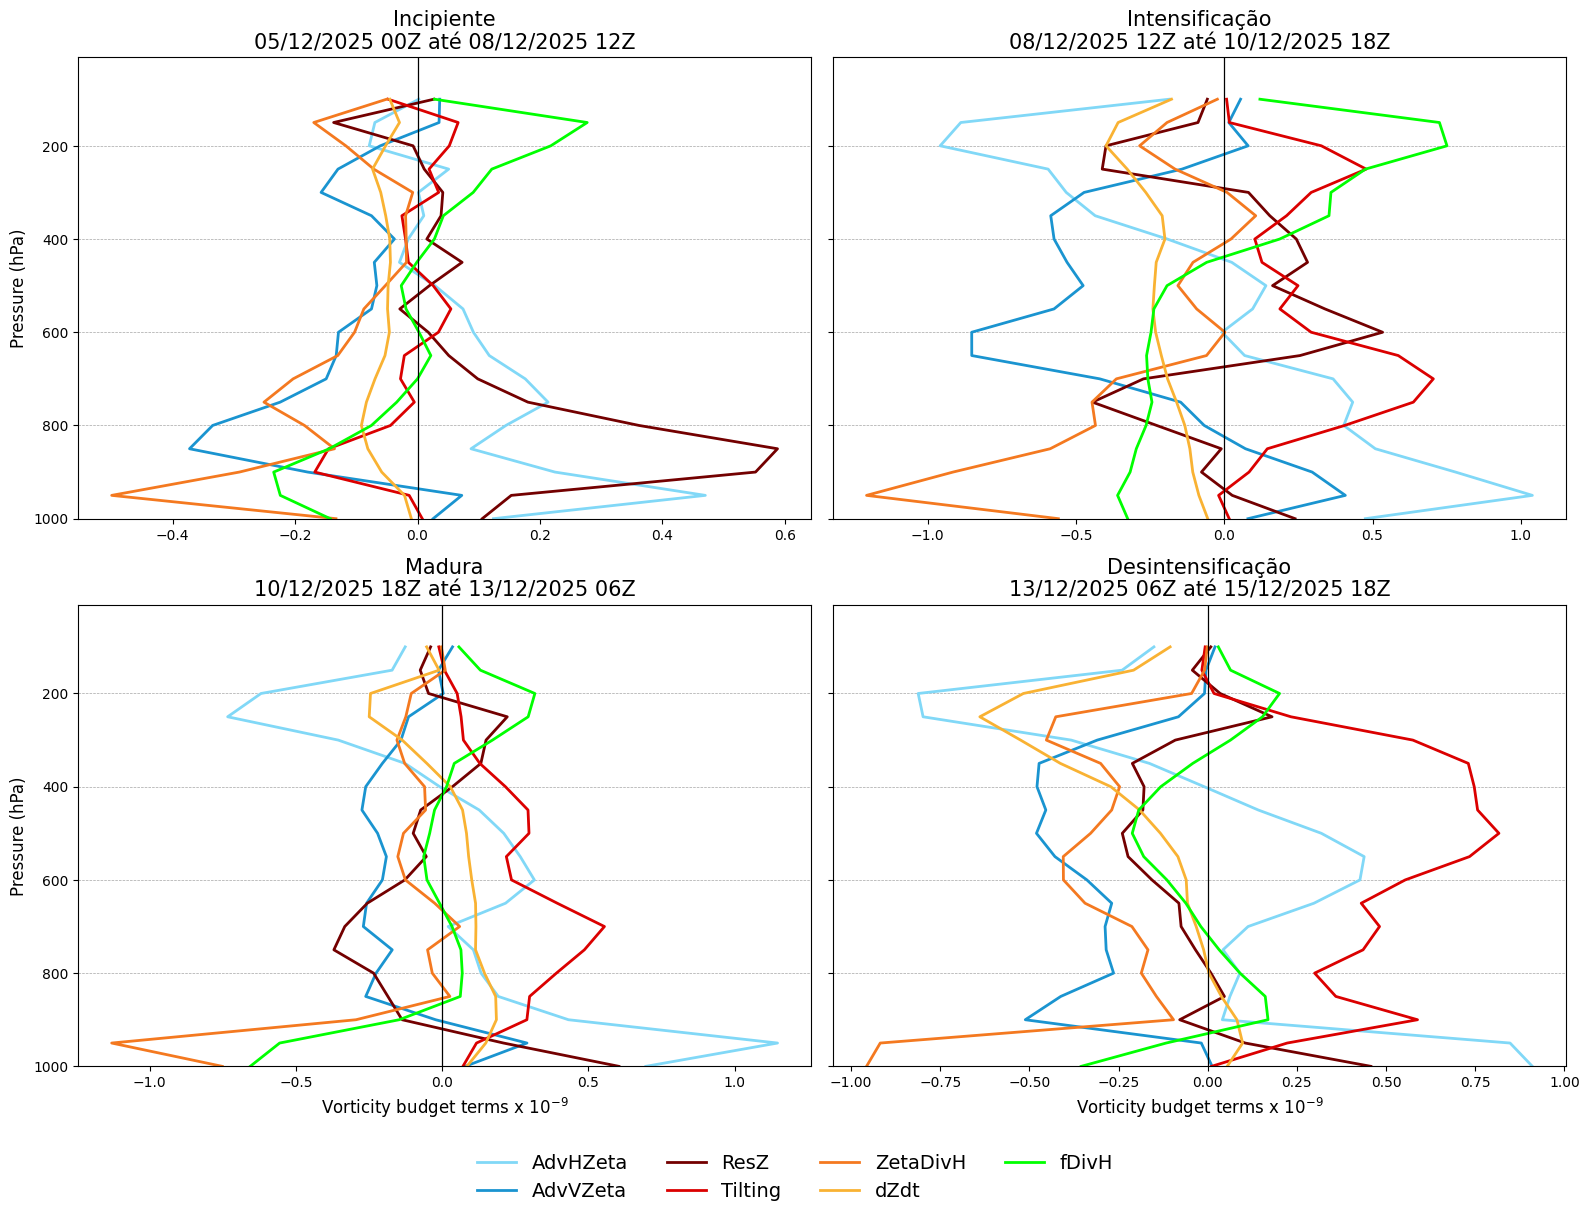

In [24]:
# @title ## <font color='#002883'> Ler .csv files do balanço de vorticidade e fazer o plot<font>

# =====================================================
# Selecionar arquivos .csv dos termos do balanço de vorticidade
# =====================================================

all_files = sorted([f for f in os.listdir(path_terms) if f.endswith('.csv')])

# Excluir variáveis que você não quer plotar
files = []
for f in all_files:
    variable = f.split('.')[0]

    if variable in ['vxBeta', 'Zeta', 'Omega', 'Sigma']:
        continue
    if 'integrated' in variable:
        continue

    files.append(f)

print("Arquivos encontrados para plot:")
for f in files:
    print(" -", f)

# ==========================================================
# Criar figura com 2 linhas x 2 colunas
# ==========================================================
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# ==========================================================
# Loop sobre as fases
# ==========================================================
for ax, (fase_nome, start_date, end_date) in zip(axes, fases):

    i = 0

    # ------------------------------------------------------
    # Loop sobre os arquivos/termos
    # ------------------------------------------------------
    for file in files:
        variable = file.split('.')[0]

        # Ler CSV
        df = pd.read_csv(os.path.join(path_terms, file), index_col=0)

        # Converter colunas para datetime
        df.columns = pd.to_datetime(df.columns)

        # Converter índice de Pa para hPa
        df.index = pd.to_numeric(df.index, errors='coerce') / 100

        # Garantir que os dados são numéricos
        df = df.apply(pd.to_numeric, errors='coerce') * 1e9

        # Selecionar o período da fase
        selected_data = df.loc[:, pd.to_datetime(start_date):pd.to_datetime(end_date)]

        # Média temporal da fase
        selected_data_mean = selected_data.mean(axis=1)

        # Plotar perfil vertical médio
        ax.plot(
            selected_data_mean.values,
            selected_data_mean.index,
            color=colors_terms[i % len(colors_terms)],
            linewidth=2,
            linestyle='solid',
            label=variable
        )

        i += 1

    # ------------------------------------------------------
    # Ajustes do subplot
    # ------------------------------------------------------
    ax.axvline(0, color='k', linewidth=0.9)
    ax.invert_yaxis()
    ax.set_ylim(1000, 10)
    ax.grid(axis='y', linestyle='--', color='gray', alpha=0.7, linewidth=0.5)

    ax.set_title(
        f'{fase_nome}\n{pd.to_datetime(start_date).strftime("%d/%m/%Y %HZ")} até {pd.to_datetime(end_date).strftime("%d/%m/%Y %HZ")}',
        fontsize=15
    )

    ax.tick_params(axis='both', labelsize=10)

# ==========================================================
# Labels apenas na borda externa
# ==========================================================
for ax in axes[2:]:
    ax.set_xlabel('Vorticity budget terms x $10^{-9}$', fontsize=12)

for ax in [axes[0], axes[2]]:
    ax.set_ylabel('Pressure (hPa)', fontsize=12)

# ==========================================================
# Legenda geral
# ==========================================================
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=4,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

# ==========================================================
# Ajuste final e salvar figura
# ==========================================================
plt.tight_layout(rect=[0, 0.05, 1, 1])

path_out = os.path.join(path_drive, 'ciclone_dec_2025_track', 'Figuras_Perfis_Verticais')
os.makedirs(path_out, exist_ok=True)

plt.savefig(
    os.path.join(path_out, f'vertical_profiles_4phases_{budget}.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **7. Acessar aos resultados dos termos do Balanço de Umidade do evento de ciclone entre 05-12-2025 até o dia 15-12-2025** <font>

In [25]:
# @title ## <font color='#002883'> Configurtações gerais para o balanço de umidade<font>
%%capture

# =====================================================
# Configurações gerais
# =====================================================

budget = 'moisture'

# Caminho da pasta com os resultados do ATMOS-BUD no drive
# (MODIFICAR PARA SEU CASO)
path_drive = '/content/drive/MyDrive/USP-CURSOS/MONITORIA/METEOROLOGIA-SINOTICA-III-2026/Aula-2_Hovmoller_Perfis-verticais'
path_terms = os.path.join(path_drive, f'ciclone_dec_2025_track/{budget}_terms')

# Fases do ciclone
fases = [
    ("Incipiente",        "2025-12-05 00:00", "2025-12-08 12:00"),
    ("Intensificação",    "2025-12-08 12:00", "2025-12-10 18:00"),
    ("Madura",            "2025-12-10 18:00", "2025-12-13 06:00"),
    ("Desintensificação", "2025-12-13 06:00", "2025-12-15 18:00"),
]

# Cores para os termos
colors_terms = [
    "#81d8f7", "#1a94d0", "#730000", "#db0000", "#f47920", "#f9b233",
    "#00ff00", "#3fae2a", "#00c1a1", "#138d75", "#ef7d90", "#cfcfcf",
    "#f6a6e1", "#b23aff", "#8377d1", "#8a9aff", "#b4e3ce",
]

<font size=4 color='#002883'> **8. Configurar DataFrame para fazer o plot dos termos do balanço de umidade** <font>

Arquivos encontrados para plot:
 - WaterBudgetResidual.csv
 - dQdt.csv
 - divQ.csv


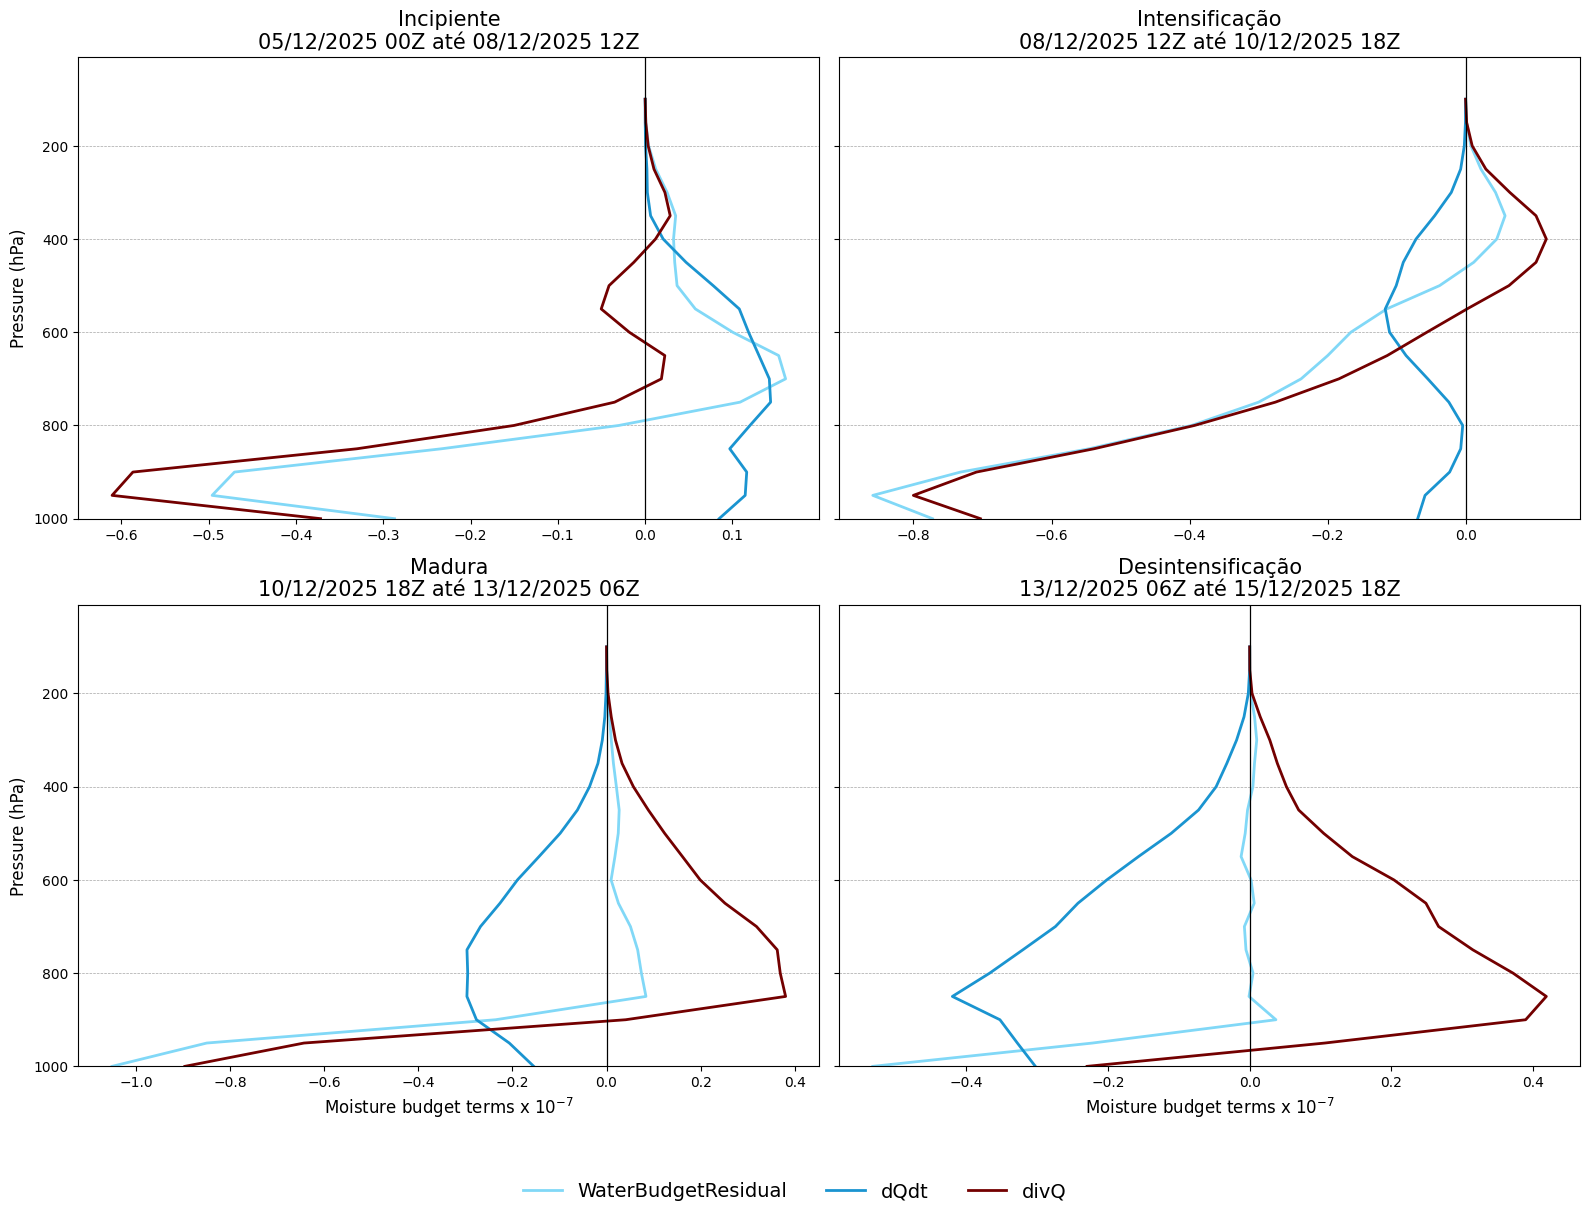

In [26]:
# @title ## <font color='#002883'> Ler .csv files do balanço de umidade e fazer o plot<font>

# =====================================================
# Selecionar arquivos .csv dos termos do balanço de umidade
# =====================================================

all_files = sorted([f for f in os.listdir(path_terms) if f.endswith('.csv')])

# Excluir variáveis que você não quer plotar
files = []
for f in all_files:
    variable = f.split('.')[0]

    if variable in ['vxBeta', 'Zeta', 'Omega', 'Sigma']:
        continue
    if 'integrated' in variable:
        continue

    files.append(f)

print("Arquivos encontrados para plot:")
for f in files:
    print(" -", f)

# ==========================================================
# Criar figura com 2 linhas x 2 colunas
# ==========================================================
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# ==========================================================
# Loop sobre as fases
# ==========================================================
for ax, (fase_nome, start_date, end_date) in zip(axes, fases):

    i = 0

    # ------------------------------------------------------
    # Loop sobre os arquivos/termos
    # ------------------------------------------------------
    for file in files:
        variable = file.split('.')[0]

        # Ler CSV
        df = pd.read_csv(os.path.join(path_terms, file), index_col=0)

        # Converter colunas para datetime
        df.columns = pd.to_datetime(df.columns)

        # Converter índice de Pa para hPa
        df.index = pd.to_numeric(df.index, errors='coerce') / 100

        # Garantir que os dados são numéricos
        df = df.apply(pd.to_numeric, errors='coerce') * 1e7

        # Selecionar o período da fase
        selected_data = df.loc[:, pd.to_datetime(start_date):pd.to_datetime(end_date)]

        # Média temporal da fase
        selected_data_mean = selected_data.mean(axis=1)

        # Plotar perfil vertical médio
        ax.plot(
            selected_data_mean.values,
            selected_data_mean.index,
            color=colors_terms[i % len(colors_terms)],
            linewidth=2,
            linestyle='solid',
            label=variable
        )

        i += 1

    # ------------------------------------------------------
    # Ajustes do subplot
    # ------------------------------------------------------
    ax.axvline(0, color='k', linewidth=0.9)
    ax.invert_yaxis()
    ax.set_ylim(1000, 10)
    ax.grid(axis='y', linestyle='--', color='gray', alpha=0.7, linewidth=0.5)

    ax.set_title(
        f'{fase_nome}\n{pd.to_datetime(start_date).strftime("%d/%m/%Y %HZ")} até {pd.to_datetime(end_date).strftime("%d/%m/%Y %HZ")}',
        fontsize=15
    )

    ax.tick_params(axis='both', labelsize=10)

# ==========================================================
# Labels apenas na borda externa
# ==========================================================
for ax in axes[2:]:
    ax.set_xlabel('Moisture budget terms x $10^{-7}$', fontsize=12)

for ax in [axes[0], axes[2]]:
    ax.set_ylabel('Pressure (hPa)', fontsize=12)

# ==========================================================
# Legenda geral
# ==========================================================
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=4,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

# ==========================================================
# Ajuste final e salvar figura
# ==========================================================
plt.tight_layout(rect=[0, 0.05, 1, 1])

path_out = os.path.join(path_drive, 'ciclone_dec_2025_track', 'Figuras_Perfis_Verticais')
os.makedirs(path_out, exist_ok=True)

plt.savefig(
    os.path.join(path_out, f'vertical_profiles_4phases_{budget}.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()